In [ ]:
##############################################################################
# AI & OPTIMIZATION - LAB 03 - 2025/2026
##############################################################################

In [1]:
# System imports
import matplotlib.pyplot as plt
import numpy as np

# Extra library imports
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
# User inputs
datafile = 'data.csv'
gps = [2.2803711895772376, 48.82639715671534]
color_dict = {1:'tab:blue', 2:'tab:green'}

Curve fitting consists in automatically finding the parameters of the curve that best fits a set of data points. It assumes that the available points follow a precise mathematical model. On this lab, we will apply the Levenberg-Marquardt approach for trajectory planning, and more particularly to track the International Space Station (ISS).

# I. Curve fitting on the ISS trajectory using the Levenberg-Marquardt algorithm

## a) Data exploration

You have trouble staying focus on today's course, you have your head in the clouds... Looking out the windows, you wonder : "will the ISS fly over us by the end of the class" ? In fact, you can follow the real-time trajectory of the ISS online (https://www.esa.int/Science_Exploration/Human_and_Robotic_Exploration/International_Space_Station/Where_is_the_International_Space_Station). You decide to collect measures on this website during 3 hours. Let's have a look at your samples.

In [3]:
# Load the csv file
df = pd.read_csv(datafile)

# Display the first five rows
print(df.head())

   LatitudeDD LatitudeCD  LongitudeDD LongitudeCD   TimeGMT  Orbit
0        19.3          S        178.6           W  12:01:23      1
1        30.5          S        168.1           W  12:05:19      1
2        43.4          S        148.9           W  12:10:41      1
3        50.2          S        127.0           W  12:15:06      1
4        51.1          S         97.5           W  12:20:07      1


Thus, for each point, you know its:
- latitude, described by both Decimal Degree (DD) and Cardinal Direction (CD)
- longitude, described by both Decimal Degree (DD) and Cardinal Direction (CD)
- hour of measure
- orbit identifier (may be arbitrary)

To draw the trajectory curves, you first have to "sign" the latitudes and longitudes. In fact, latitudes associated to South (S), and longitudes associated to West (W) should be multiplied by "-1".

<font color='blue'> Question 1: change the values in the columns "LatitudeDD" and "LongitudeDD" to obtain signed values.
</font>  

In [4]:
print(len(df))

40


In [8]:
df.loc[df['LatitudeCD'] == 'S', 'LatitudeDD'] *= -1
df.loc[df['LongitudeCD'] == 'W', 'LongitudeDD'] *= -1

We can now plot the trajectory of the ISS during the 3 hours! 

# Affichage
<font color='blue'> Question 2: plot the signed latitude values in function of the signed longitude values. Represent each orbit points with the colors indicated in the "color_dict" dictionary. Plot also in red the GPS coordinated of ISEP, available in the "gps" list.
</font>  

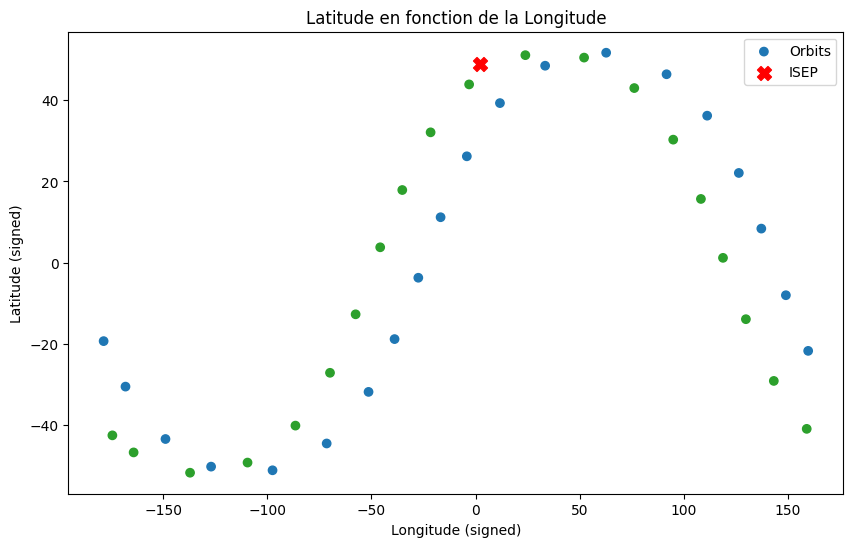

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df['LongitudeDD'], df['LatitudeDD'], c=df['Orbit'].map(color_dict), label='Orbits')
plt.scatter(gps[0], gps[1], color='red', marker='X', s=100, label='ISEP')
plt.xlabel('Longitude (signed)')
plt.ylabel('Latitude (signed)')
plt.title('Latitude en fonction de la Longitude')
plt.legend()

You should see that the ISS flew over Isep during the presumed second orbit. To estimate the associated time, we can use a nearest neighbors approach: we select the closest measured point, and display its associated time.

<font color='blue'> Question 3: get the measured point closest to Isep, in terms of Euclidian distance using the latitude and longitude for simplification. Repeat question 2, highlighting the closest measured point. Display also the associated time.
</font>  

14:40:13


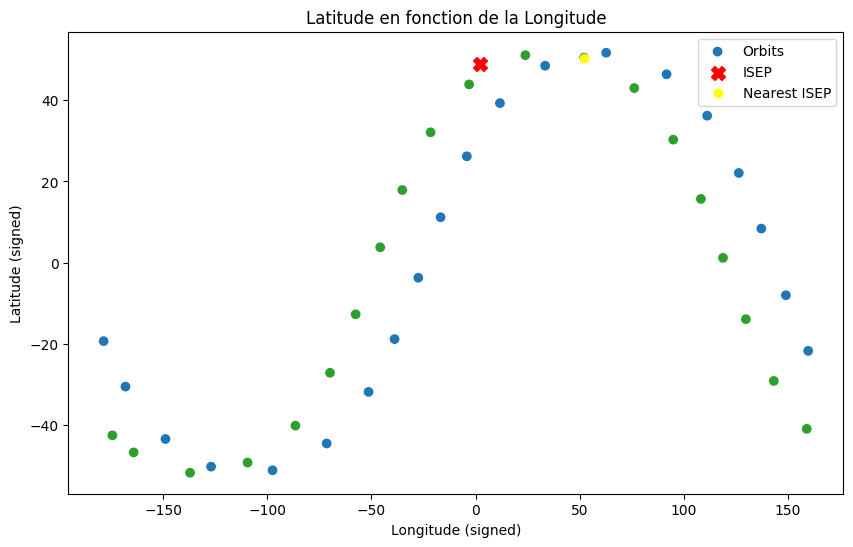

In [17]:
# on établit toutes les distances
distances = np.sqrt((df['LatitudeDD'] - gps[0])**2 + (df['LongitudeDD'] - gps[1])**2)
# ensuite on cherche les minimum 
idx_closest = distances.idxmin()

near_lat = df.loc[idx_closest, 'LatitudeDD']
near_lon = df.loc[idx_closest, 'LongitudeDD']
Time = df.loc[idx_closest,'TimeGMT']

plt.figure(figsize=(10,6))
plt.scatter(df['LongitudeDD'], df['LatitudeDD'], c=df['Orbit'].map(color_dict), label='Orbits')
plt.scatter(gps[0], gps[1], color='red', marker='X', s=100, label='ISEP')
plt.scatter(near_lon,near_lat, color='yellow', label = 'Nearest ISEP')
plt.xlabel('Longitude (signed)')
plt.ylabel('Latitude (signed)')
plt.title('Latitude en fonction de la Longitude')
plt.legend()
print(Time)

Thus, we have an idea about the expected flying time over Isep. Looking at the above figures, the latitude of the ISS looks like a sinusoidal function of the longitude, delayed at each new orbit. We are first going to check this assumption.

## b) Trajectory fitting: latitude as a function of longitude

We will now use the Levenberg-Marquardt method to fit a sinusoidal function to each orbit data. In our application, the algorithm minimizes the following loss for each orbit $j$:

 $\frac{1}{2} \displaystyle \sum_{i=1}^{n_j} (y_i - w_0 * sin(w_1 * \pi  /  180 * x_i + w_2) ) ^ 2$ 
 
 with $n_j$ the number of samples of orbit $j$ in the dataset, $y_i$ the associated latitudes, $x_i$ the associated longitudes, and $\boldsymbol w = [w_0, w_1, w_2]$ the vector of variables to optimize.

<font color='blue'> Question 4: complete the function below to write  $\boldsymbol y$ as a function of $\boldsymbol x$, $w_0$, $w_1$ and $w_2$.
</font>  

In [18]:
def predict(x, w0, w1, w2): 

    """
    The model function 
    
    Parameters
    ----------
    x: 1D array
        the array containing the x values 
    w0: float
        the w_0 variable
    w1: float
        the w_1 variable
    w2: float
        the 2 variable
        
    Returns
    -------
    y: vector
        the values of the fitted input data y
        
    Command:
    y = predict(x, w0, w1, w2)
    
    """
    # Write y as a function of x, w0, w1 and w2
    
    y = w0 * np.sin(w1 * np.pi / 180 * x + w2)
    
    return y

We will now perform the sinusoidal fitting.

<font color='blue'> Question 5: for each orbit
- Compute the vectors containing the $x_i$ and $y_i$ values 
- Perform optimization using the "curve_fit" function from Scipy
- Display the optimized values of $w_0$, $w_1$ and $w_2$
- Display the optimized loss value   
- Display the difference in absolute value between the true and predicted latitude values at ISEP
- Repeat question 2 adding the fitted sinusoidal curve 
</font>  

--- Orbit 1 ---
Optimized parameters: w0=57.14, w1=1.06, w2=0.47
Loss: 118.73661954334295
Absolute diff at ISEP: 53.8098°

--- Orbit 2 ---
Optimized parameters: w0=57.34, w1=1.08, w2=0.91
Loss: 114.53583271499024
Absolute diff at ISEP: 53.2412°



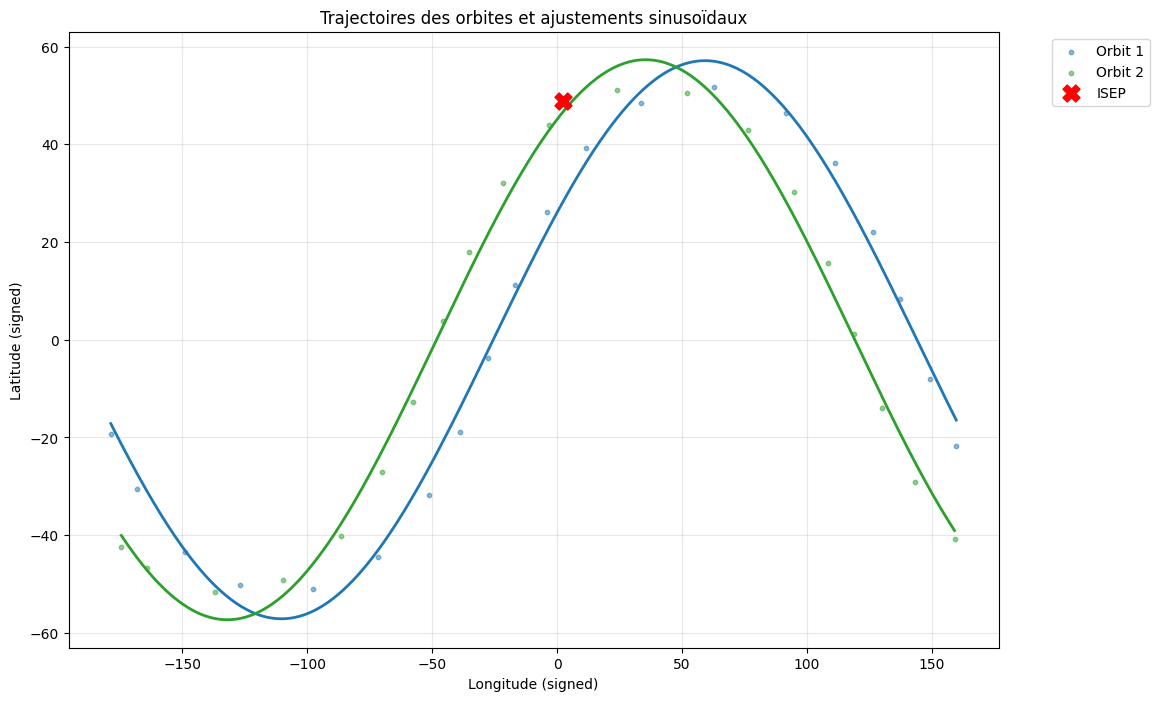

In [21]:
initial_guess = [60, 1, 0]
results = {}

plt.figure(figsize=(12, 8))
for orbit_id in df['Orbit'].unique():
    orbit_data = df[df['Orbit'] == orbit_id]
    x_orbit = orbit_data['LongitudeDD'].values
    y_orbit = orbit_data['LatitudeDD'].values
    
    popt, _ = curve_fit(predict, x_orbit, y_orbit, p0=initial_guess)
    w0_opt, w1_opt, w2_opt = popt

    y_pred = predict(x_orbit, w0_opt, w1_opt, w2_opt)
    loss = 0.5 * np.sum((y_orbit - y_pred)**2)
    
    
    lat_isep_pred = predict(gps[1], w0_opt, w1_opt, w2_opt)
    diff_isep = abs(gps[0] - lat_isep_pred)
    
    # Affichage des résultats pour chaque orbite
    print(f"--- Orbit {orbit_id} ---")
    print(f"Optimized parameters: w0={w0_opt:.2f}, w1={w1_opt:.2f}, w2={w2_opt:.2f}")
    print(f"Loss: {loss}")
    print(f"Absolute diff at ISEP: {diff_isep:.4f}°\n")
    

    plt.scatter(x_orbit, y_orbit, color=color_dict[orbit_id], label=f'Orbit {orbit_id}', s=10, alpha=0.5)
    
    # On trace la courbe sinusoïdale continue
    x_range = np.linspace(x_orbit.min(), x_orbit.max(), 500)
    plt.plot(x_range, predict(x_range, *popt), color=color_dict[orbit_id], linewidth=2)

# Ajout de l'ISEP en rouge
plt.scatter(gps[0], gps[1], color='red', marker='X', s=150, label='ISEP', zorder=5)

plt.xlabel('Longitude (signed)')
plt.ylabel('Latitude (signed)')
plt.title('Trajectoires des orbites et ajustements sinusoïdaux')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

<font color='blue'> Question 6: compare the two fitted sinusoidal functions. According to the proposed models, during which orbit the ISS had the highest chance to be observed from Isep ? Conclude on the validity of the proposed models. 
</font>  

<font color='green'> To complete
</font>  

To determine precisely when the ISS flew over ISEP, we have to formulate a model involving time. We will now assume that latitude can be expressed as a function of time.

## c) Trajectory fitting: latitude as a function of time

For each measured sample, the time is expressed in hour:minutes:seconds. However, it should be converted into seconds to be used in a model. Moreover, we assume that each time sample should then be normalized a follows:

$t_i^{norm} = \frac{t_i - \displaystyle \min_j t_j}{\displaystyle \max_j t_j- \displaystyle \min_j t_j}$

with $t_i$ the jth time sample expressed in seconds.

<font color='blue'> Question 7: convert the time samples into seconds, and then normalize them. You can use the *split* function.
</font>  

In [27]:
def convert_time(t_str):
    h, m, s = map(int, t_str.split(':'))
    return h*3600 + m * 60 + s 

df['Time_Sec'] = df['TimeGMT'].apply(convert_time)

df['Time_Norm'] = (df['Time_Sec'] - df['Time_Sec'].min()) / (df['Time_Sec'].max() - df['Time_Sec'].min())


We can now visualize the latitude values as a function of time expressed in seconds and normalized.

<font color='blue'> Question 8: plot the signed latitude values in function of the normalized time values expressed in seconds. Represent each orbit points with the colors indicated in the "color_dict" dictionary. Plot also a red line representing the latitude of ISEP (available in the "gps" list).
</font>  

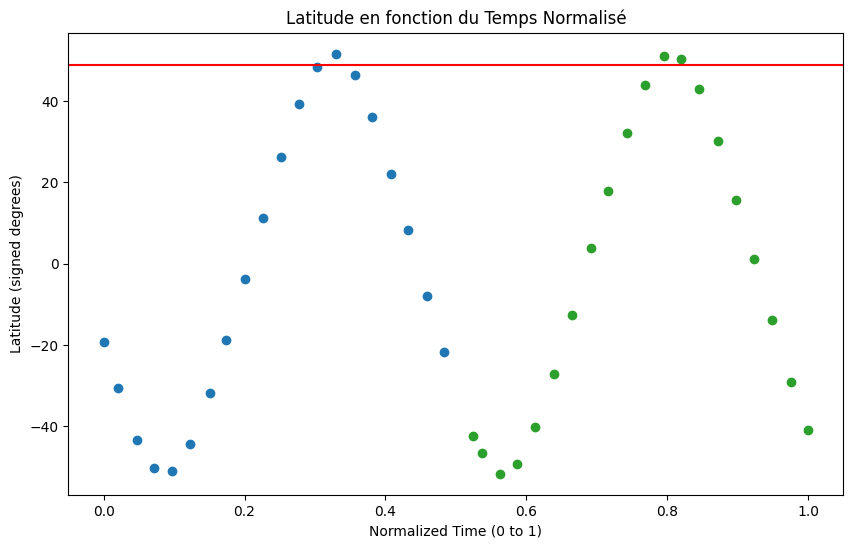

In [28]:


plt.figure(figsize=(10, 6))


for orbit_id in df['Orbit'].unique():
    orbit_data = df[df['Orbit'] == orbit_id]
    plt.scatter(orbit_data['Time_Norm'], orbit_data['LatitudeDD'], color=color_dict[orbit_id], label=f'Orbit {orbit_id}')


plt.axhline(y=gps[1], color='red',label='ISEP Latitude')


plt.xlabel('Normalized Time (0 to 1)')
plt.ylabel('Latitude (signed degrees)')
plt.title('Latitude en fonction du Temps Normalisé')
plt.show()


Looking at the above figure, the latitude of the ISS looks like a sinusoidal function of the time. We will now check this assumption.

<font color='blue'> Question 9:
- Compute the vectors containing the $x_i$ and $y_i$ values 
- Perform optimization using the "curve_fit" function from Scipy
- Display the optimized values of $w_0$, $w_1$ and $w_2$
- Display the optimized loss value   
- Repeat question 8 adding the fitted sinusoidal curve 
- Conclude on the validity of this model
</font>  

In [ ]:
# ... To complete ...

<font color='green'> To complete
</font>  

Now we know that the ISS flew over ISEP during the course, we can be more specific: when?
We propose to answer this question formulating a relevant optimization constrained problem with one unknow variable: time. Moreover, we can add time bounds using the dataset.

<font color='blue'> Question 10: estimate the time the ISS flew over ISEP following the steps below:
* automatically select time bounds from the dataset, *i.e.* $t_{min}$ and $t_{max}$ such as the expected time t should be in $[t_{min}, t_{max}]$
* formulate a loss function to minimize to obtain the time depending on w0, w1, w2 and gps[1]
* find the time the ISS flew over ISEP using the Powell method (you have to use the "minimize" function of Scipy with the approriate arguments)
* convert this time into hour:minutes:seconds    
    
</font>  

In [ ]:
# ... To complete ...